# Question 6 PCA + Classification

In [2]:

import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [3]:
class PCA:
    """
      Principal Component Analysis (PCA) implementation.
    """
    def __init__(self, n_components):
        """ Initialize PCA with the number of components to keep. """
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        """ Fit the PCA model to the data X. """
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]
        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio_ = eigenvalues / np.sum(eigenvalues)

    def transform(self, X):
        """ Apply the dimensionality reduction on X. """
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def inverse_transform(self, X_reduced):
        """ Transform the reduced data back to the original space. """
        return np.dot(X_reduced, self.components.T) + self.mean

    def checkPCA(self, X):
        """ Check if the PCA transformation is correct. """
        X_reduced = self.transform(X)
        return X_reduced.shape[1] == self.n_components

In [4]:
digits = datasets.load_digits()
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [5]:
n_components_list = [2, 5, 10,20, 30, 40, 50, 64]
X_trained= []
X_tested= []
for n in n_components_list:
    pca = PCA(n_components=n)
    pca.fit(X_train)
    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)
    X_trained.append(X_train_pca)
    X_tested.append(X_test_pca)
    print(f"Number of components: {n}")
    var = pca.explained_variance_ratio_[:n].sum()
    print(f"Total explained variance ratio: {var}\n")



Number of components: 2
Total explained variance ratio: 0.217711038132041

Number of components: 5
Total explained variance ratio: 0.4171461578185228

Number of components: 10
Total explained variance ratio: 0.5923315422354275

Number of components: 20
Total explained variance ratio: 0.7960052034490993

Number of components: 30
Total explained variance ratio: 0.8956178801843089

Number of components: 40
Total explained variance ratio: 0.9518060732050218

Number of components: 50
Total explained variance ratio: 0.9833530639634809

Number of components: 64
Total explained variance ratio: 1.0



In [15]:
k_values = [5 , 25 ,50 ,100]
accuracy_results = []
for i in range (len(X_trained)):
    X_train_pca = X_trained[i]
    X_test_pca = X_tested[i]
    # fiiting the knn on the training data
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_pca, y_train.ravel())
        y_pred = knn.predict(X_test_pca)
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_results.append((n_components_list[i], k, accuracy))
        print(f"Number of components: {n_components_list[i]}, k={k}, Accuracy: {accuracy:.4f}")
    

Number of components: 2, k=5, Accuracy: 0.5528
Number of components: 2, k=25, Accuracy: 0.5778
Number of components: 2, k=50, Accuracy: 0.5611
Number of components: 2, k=100, Accuracy: 0.5361
Number of components: 5, k=5, Accuracy: 0.8972
Number of components: 5, k=25, Accuracy: 0.8556
Number of components: 5, k=50, Accuracy: 0.8278
Number of components: 5, k=100, Accuracy: 0.8000
Number of components: 10, k=5, Accuracy: 0.9222
Number of components: 10, k=25, Accuracy: 0.9083
Number of components: 10, k=50, Accuracy: 0.8667
Number of components: 10, k=100, Accuracy: 0.8556
Number of components: 20, k=5, Accuracy: 0.9639
Number of components: 20, k=25, Accuracy: 0.9389
Number of components: 20, k=50, Accuracy: 0.9222
Number of components: 20, k=100, Accuracy: 0.9083
Number of components: 30, k=5, Accuracy: 0.9722
Number of components: 30, k=25, Accuracy: 0.9472
Number of components: 30, k=50, Accuracy: 0.9278
Number of components: 30, k=100, Accuracy: 0.9083
Number of components: 40, k=

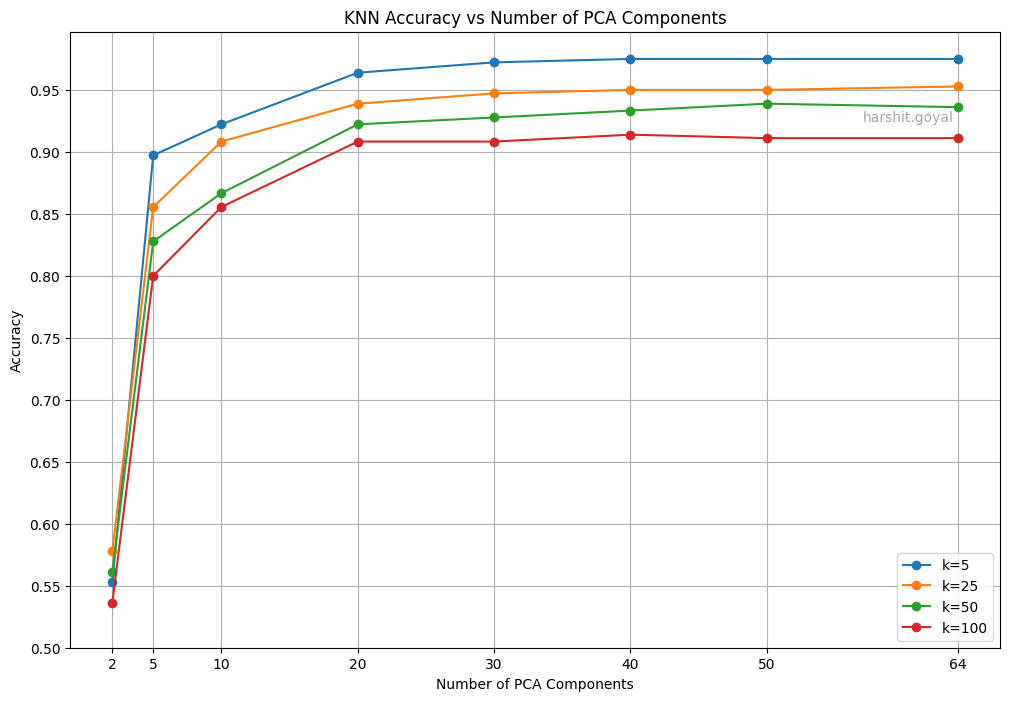

In [16]:
# creating a visualization of the accuracy results

accuracy_df = np.array(accuracy_results)
accuracy_df = accuracy_df.reshape(len(n_components_list), len(k_values), 3)
plt.figure(figsize=(12, 8))
for idx, k in enumerate(k_values):
    accuracies = accuracy_df[:, idx, 2]
    plt.plot(n_components_list, accuracies, marker='o', label=f'k={k}')
plt.title('KNN Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.yticks(np.arange(0.5, 1, 0.05))
plt.xticks(n_components_list)
plt.legend(loc=4)
plt.text(0.95, 0.85, "harshit.goyal", ha='right', va='bottom', transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.grid()
plt.show()


- Effect of number of principal components (n_components)
    - Accuracy increases rapidly as the number of components increases from very low values (e.g., 2 → 10).
    - After ~30–40 components, the improvement slows down, indicating diminishing returns.
    - Using all 64 components (full dimension) gives the highest accuracy, but the gain over 40–50 components is marginal.
- Effect of K in KNN
    - Smaller k (like 5) tends to give slightly higher accuracy on smaller component sets, because the classifier is more sensitive to local structure.
    - Larger k (50, 100) can slightly reduce accuracy, especially at very low PCA dimensions, because averaging over many neighbors smooths distinctions between classes.
    - As dimensionality increases, the effect of k becomes less significant.
- Diminishing returns
    - Beyond ~40–50 components, adding more dimensions does not significantly improve accuracy.
    - This aligns with the explained variance plot: most of the variance is captured by the first 40–50 components, so extra components add little useful information for classification.